<a href="https://colab.research.google.com/github/BandaAkshitha/OIBSIP/blob/main/Akshitha_Task01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

Load Dataset

In [61]:
df = pd.read_csv('/content/Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Dataset Information

In [62]:
print("Shape of Dataset:", df.shape)

df.info()

df.describe()

Shape of Dataset: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Check Missing Values

In [63]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


Check Species Distribution

In [64]:
print(df['Species'].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Species Distribution Plot

/tmp/ipykernel_2691/714746022.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


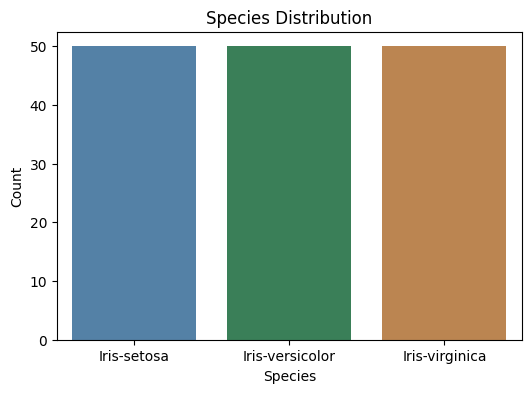

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Species',
    data=df,
    palette=['steelblue', 'seagreen', 'peru']
)

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")

plt.savefig("species_distribution.png", bbox_inches='tight')
plt.show()

Pairplot

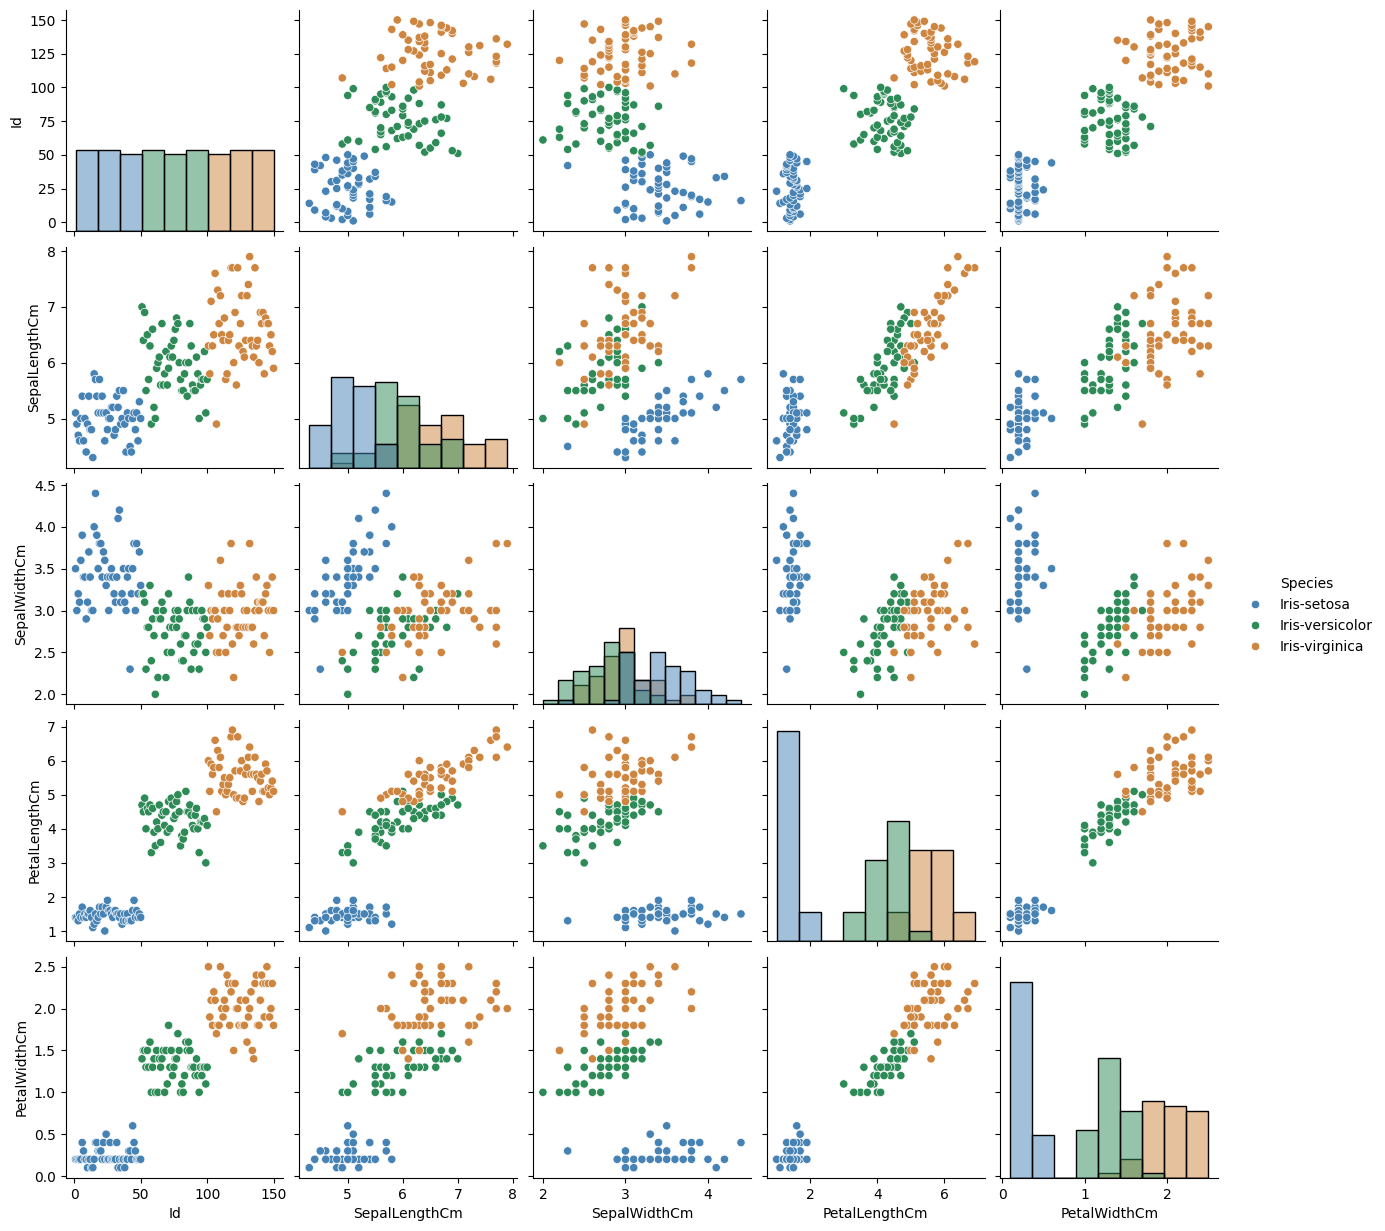

In [66]:
sns.pairplot(
    df,
    hue='Species',
    palette=['steelblue', 'seagreen', 'peru'],
    diag_kind='hist'
)

plt.savefig("pairplot.png", bbox_inches='tight')
plt.show()

Correlation Heatmap

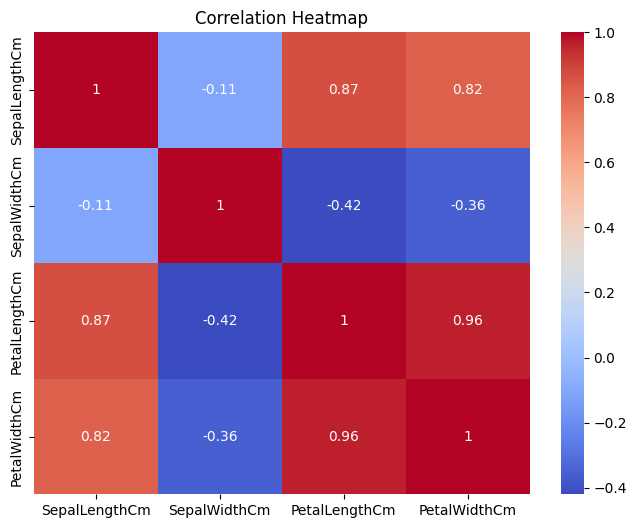

In [67]:
plt.figure(figsize=(8,6))

corr = df.drop(['Id'], axis=1).select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("heatmap.png", bbox_inches='tight')

plt.show()

Boxplot

/tmp/ipykernel_2691/1672058157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


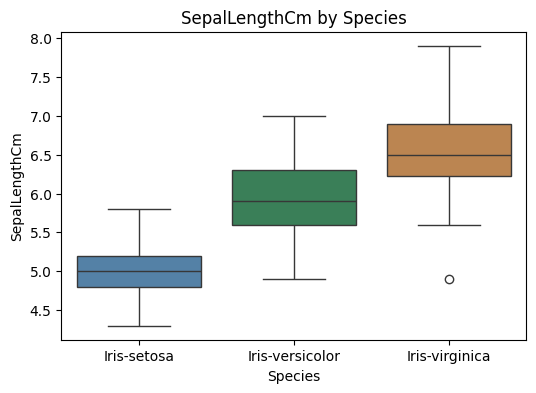

/tmp/ipykernel_2691/1672058157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


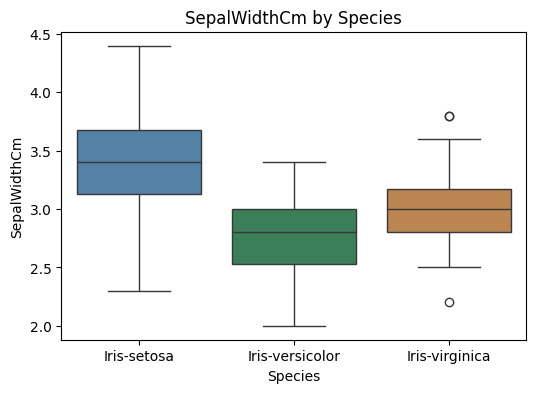

/tmp/ipykernel_2691/1672058157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


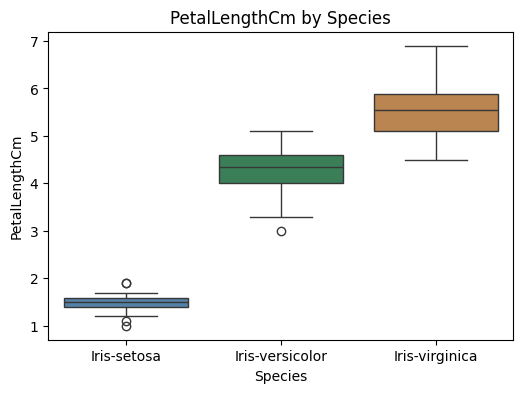

/tmp/ipykernel_2691/1672058157.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


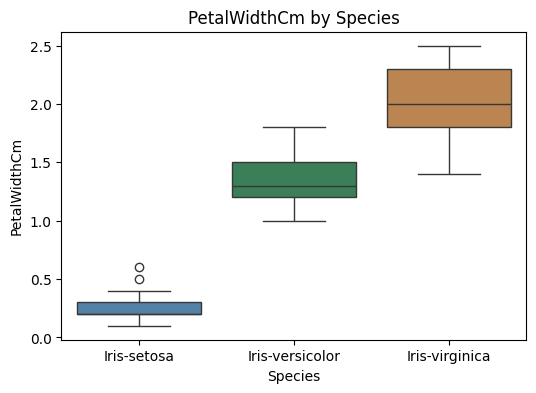

In [68]:
features = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x='Species',
        y=feature,
        data=df,
        palette=['steelblue', 'seagreen', 'peru']
    )

    plt.title(f"{feature} by Species")

    plt.savefig(
        f"{feature}_boxplot.png",
        bbox_inches='tight'
    )

    plt.show()

Prepare Data

In [69]:
X = df.drop(['Id','Species'], axis=1)

y = df['Species']

Train-Test Split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


Logistic Regression

In [71]:
lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 1.0


Decision Tree

In [72]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


Random Forest

In [73]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


KNN

In [74]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 1.0


Compare All Models

In [75]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        lr_acc,
        dt_acc,
        rf_acc,
        knn_acc
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2        Random Forest       1.0
3                  KNN       1.0


Accuracy Comparison Graph

/tmp/ipykernel_2691/3003914118.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


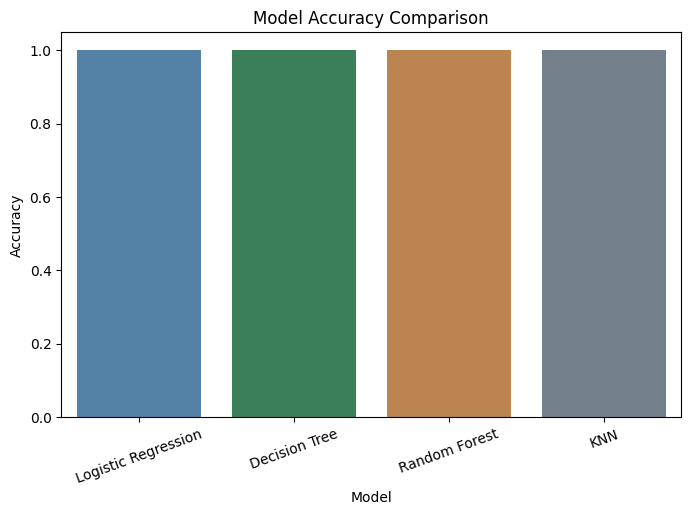

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results,
    palette=['steelblue', 'seagreen', 'peru', 'slategray']
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.savefig(
    "model_comparison.png",
    bbox_inches='tight'
)

plt.show()

Best Model Confusion Matrix

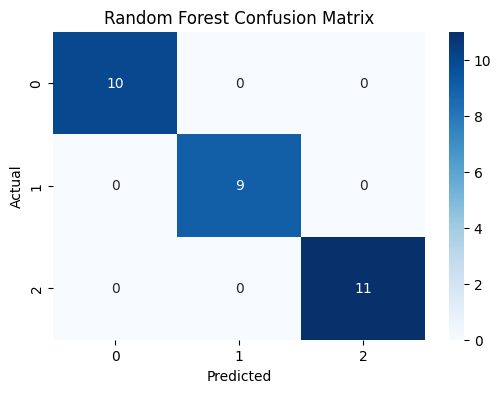

In [77]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

Classification Report

In [78]:
print(classification_report(y_test, rf_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Feature Importance

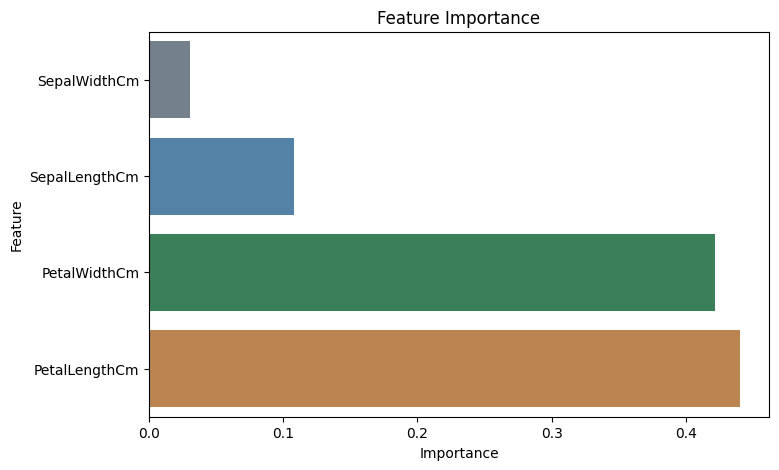

In [79]:
feature_importances = rf.feature_importances_
features = X.columns

importance = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

importance = importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    hue='Feature',
    palette=['slategray', 'steelblue', 'seagreen', 'peru'],
    legend=False
)

plt.title("Feature Importance")

plt.savefig(
    "feature_importance.png",
    bbox_inches='tight'
)

plt.show()

Save Results CSV

In [80]:
results.to_csv(
    "model_accuracy_results.csv",
    index=False
)

print("Results Saved Successfully!")

Results Saved Successfully!


/tmp/ipykernel_2691/3607421632.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2691/3607421632.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2691/3607421632.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2691/3607421632.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2691/3607421632.py:44: FutureWarning: 



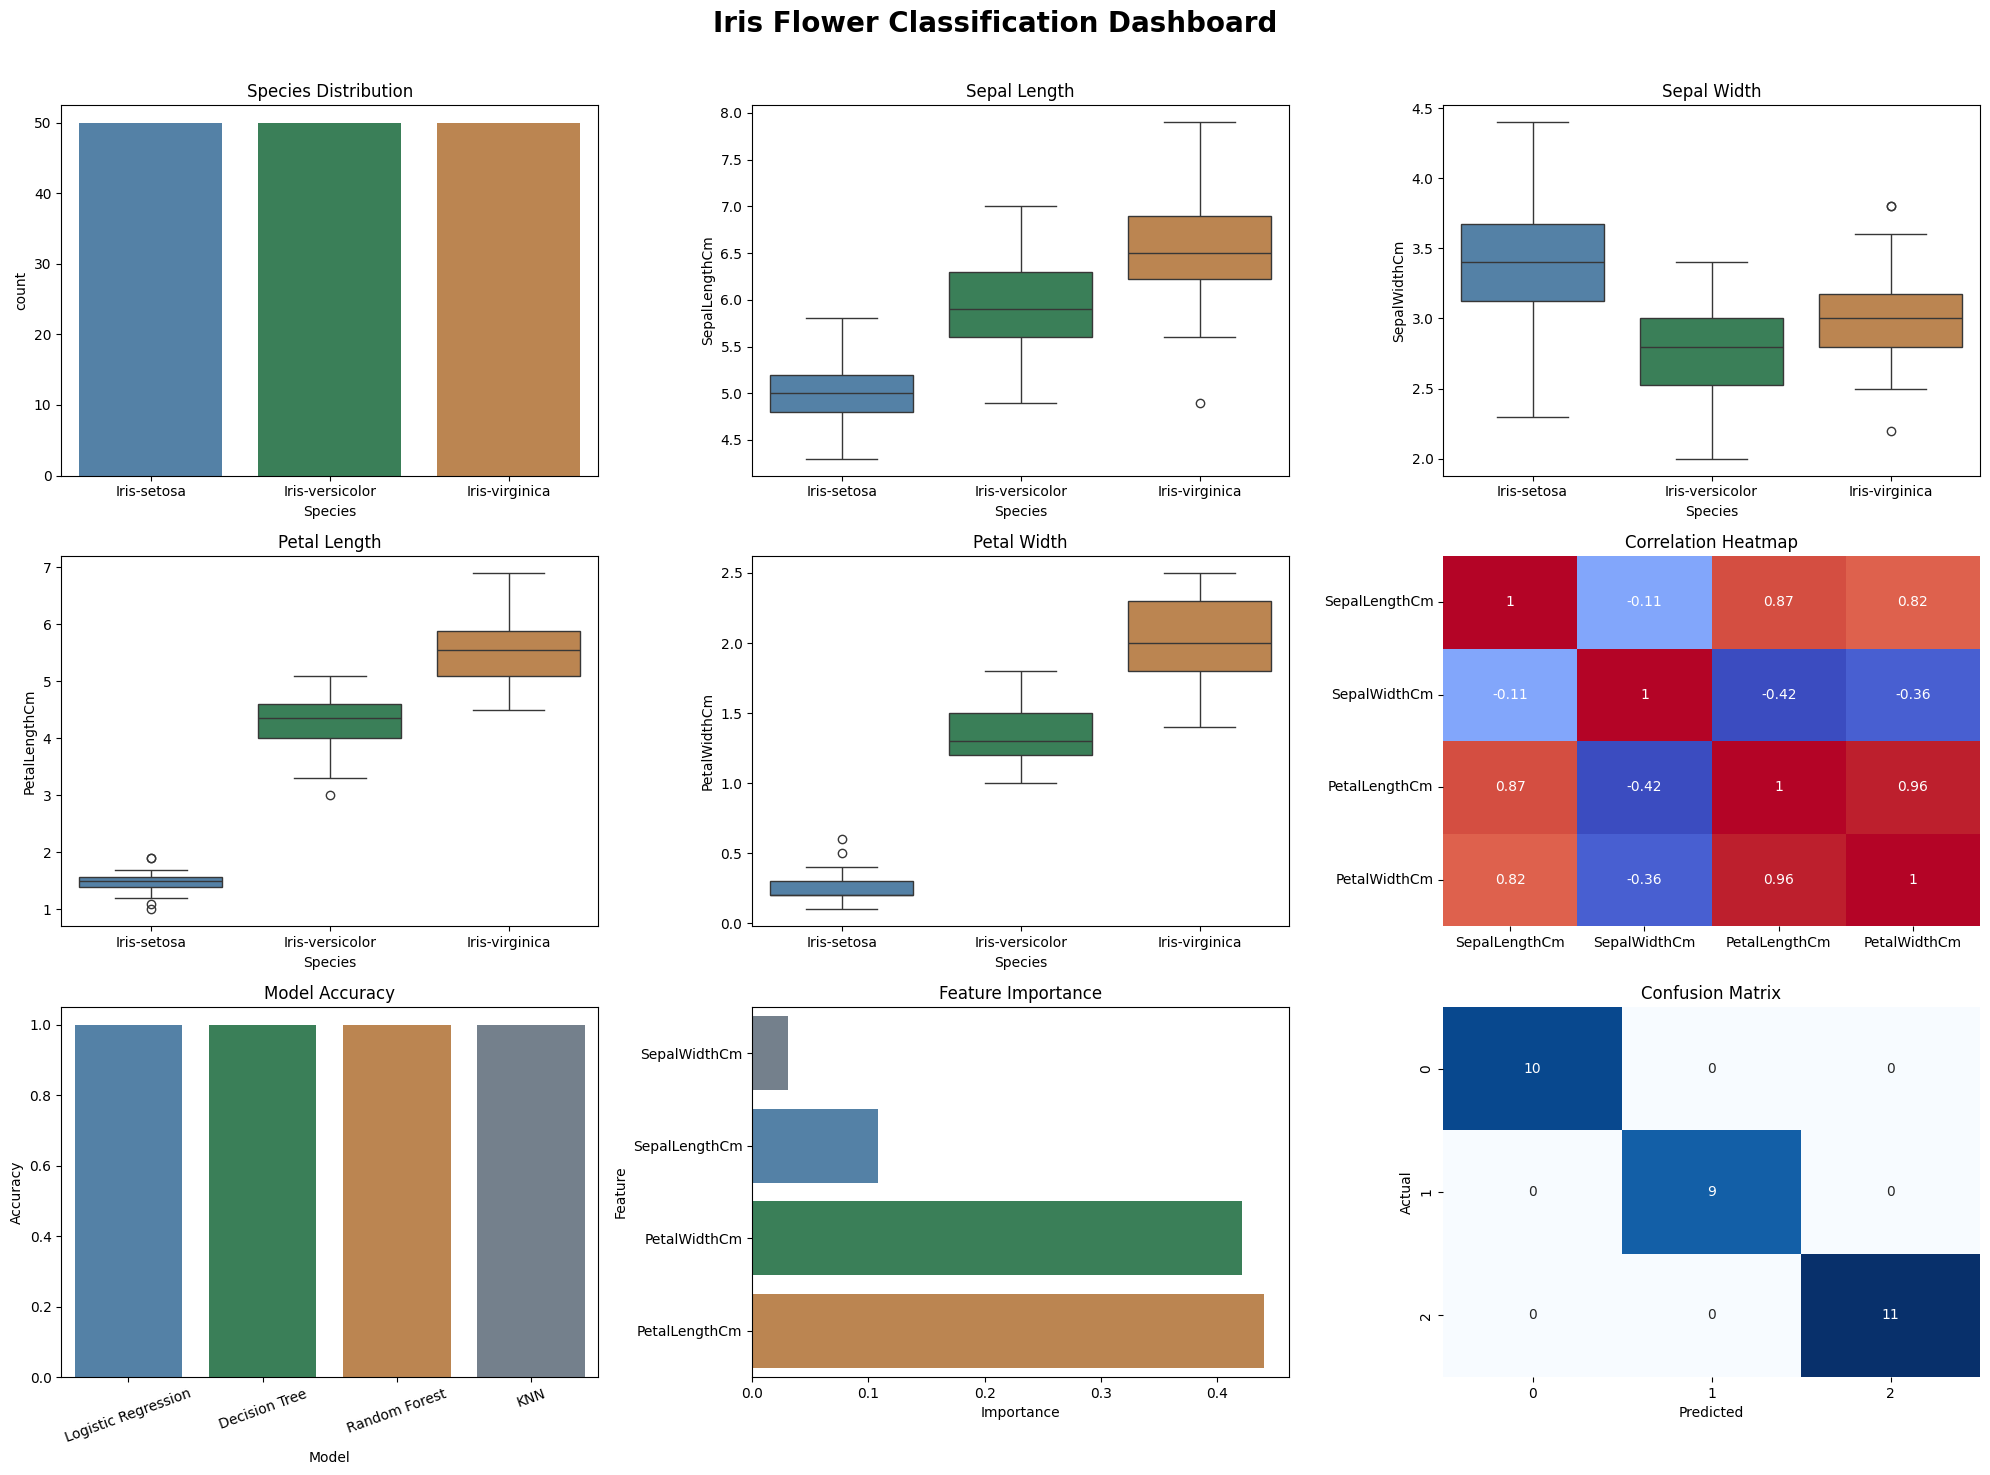

In [81]:
plt.figure(figsize=(20,15))

# 1. Species Distribution
plt.subplot(3,3,1)
sns.countplot(
    x='Species',
    data=df,
    palette=['steelblue', 'seagreen', 'peru']
)
plt.title("Species Distribution")

# 2. Sepal Length
plt.subplot(3,3,2)
sns.boxplot(
    x='Species',
    y='SepalLengthCm',
    data=df,
    palette=['steelblue', 'seagreen', 'peru']
)
plt.title("Sepal Length")

# 3. Sepal Width
plt.subplot(3,3,3)
sns.boxplot(
    x='Species',
    y='SepalWidthCm',
    data=df,
    palette=['steelblue', 'seagreen', 'peru']
)
plt.title("Sepal Width")

# 4. Petal Length
plt.subplot(3,3,4)
sns.boxplot(
    x='Species',
    y='PetalLengthCm',
    data=df,
    palette=['steelblue', 'seagreen', 'peru']
)
plt.title("Petal Length")

# 5. Petal Width
plt.subplot(3,3,5)
sns.boxplot(
    x='Species',
    y='PetalWidthCm',
    data=df,
    palette=['steelblue', 'seagreen', 'peru']
)
plt.title("Petal Width")

# 6. Correlation Heatmap
plt.subplot(3,3,6)
corr = df.drop(['Id'], axis=1).select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    cbar=False
)
plt.title("Correlation Heatmap")

# 7. Model Accuracy Comparison
plt.subplot(3,3,7)
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results,
    palette=['steelblue', 'seagreen', 'peru', 'slategray']
)
plt.title("Model Accuracy")
plt.xticks(rotation=20)

# 8. Feature Importance
plt.subplot(3,3,8)
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette=['slategray', 'steelblue', 'seagreen', 'peru']
)
plt.title("Feature Importance")

# 9. Confusion Matrix
plt.subplot(3,3,9)
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.suptitle(
    "Iris Flower Classification Dashboard",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "iris_classification_dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()